In [ ]:
import my_data_manager as mdm

cat = mdm.load_cat("galaxies_subhalos_zphot.cat")
halos = mdm.separate_halos(cat)
clusters, groups = mdm.separate_clusters(halos)

/mnt/c/Users/gasep/OneDrive/Documentos/GitHub/ClusteringComparison/ClusteringComparison/my_data_manager.py:53: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(cat, delim_whitespace=True, header=None)
/mnt/c/Users/gasep/OneDrive/Documentos/GitHub/ClusteringComparison/ClusteringComparison/my_data_manager.py:53: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cat, delim_whitespace=True, header=None)


In [2]:
print(len(clusters))

731


In [3]:
print(clusters[0].columns)

Index(['galaxyId', 'haloId', 'pos_x', 'pos_y', 'pos_z', 'vel_x', 'vel_y',
       'vel_z', 'redshift', 'snapshot', 'sfr', 'm_star', 'm_coldgas',
       'Z_coldgas', 'R_coldgas', 'sfh_bin', 'sfh_nbin', 'RA', 'DEC', 'z_geo',
       'd_comoving', 'z_app', 'mag_u', 'mag_g', 'mag_r', 'mag_i', 'mag_z',
       'z_phot', 'firstHaloInFOFGroupId', 'log(m_200)'],
      dtype='object', name=0)


In [4]:
import pandas as pd

N = 21

clean_clusters = [df[df.groupby('haloId')['haloId'].transform('count') > 3] for df in clusters]
splus_clusters = [df[pd.to_numeric(df['mag_r'], errors='coerce') >= N].copy() for df in clusters]

In [5]:
from astropy.stats import biweight_location
import astro_utils as au

redshifts = []
masses = []
r_200 = []

for df in clusters:
    avg_z_app = biweight_location(df['z_app'].astype(float))
    log_m200 = float(df['log(m_200)'].iloc[0])
    
    redshifts.append(avg_z_app)
    masses.append(log_m200)
    r_200.append(au.get_r_200(log_m200, avg_z_app, H0=67.3, Om0=0.315))

In [6]:
import numpy as np

avg_z_app = np.mean(redshifts)
med_z_app = np.median(redshifts)
std_z_app = np.std(redshifts)
print(f"Average z_app: {avg_z_app:.3f} ± {std_z_app:.3f}")
print(f"Median z_app: {med_z_app:.3f} ± {std_z_app:.3f}")

max_z_app = np.max(redshifts)
min_z_app = np.min(redshifts)
print(f"Max z_app: {max_z_app:.3f}")
print(f"Min z_app: {min_z_app:.3f}")

stellar_masses = [10**m for m in masses]
avg_m200 = np.mean(stellar_masses)
med_m200 = np.median(stellar_masses)
std_m200 = np.std(stellar_masses)
avg_m200 = np.log10(avg_m200)
med_m200 = np.log10(med_m200)
std_m200 = np.log10(std_m200)
print(f"Average log(m_200): {avg_m200:.3f} ± {std_m200:.3f}")
print(f"Median log(m_200): {med_m200:.3f} ± {std_m200:.3f}")

max_m200 = np.max(masses)
min_m200 = np.min(masses)
print(f"Max log(m_200): {max_m200:.3f}")    
print(f"Min log(m_200): {min_m200:.3f}")

avg_r_200 = np.mean(r_200)
med_r_200 = np.median(r_200)
std_r_200 = np.std(r_200)
print(f"Average r_200: {avg_r_200:.3f} ± {std_r_200:.3f}")
print(f"Median r_200: {med_r_200:.3f} ± {std_r_200:.3f}")

max_r_200 = np.max(r_200)
min_r_200 = np.min(r_200)
print(f"Max r_200: {max_r_200:.3f}")
print(f"Min r_200: {min_r_200:.3f}")

Average z_app: 0.388 ± 0.123
Median z_app: 0.405 ± 0.123
Max z_app: 0.577
Min z_app: 0.046
Average log(m_200): 14.512 ± 14.358
Median log(m_200): 14.421 ± 14.358
Max log(m_200): 15.531
Min log(m_200): 14.116
Average r_200: 1.227 ± 0.213
Median r_200: 1.173 ± 0.213
Max r_200: 2.875
Min r_200: 0.993


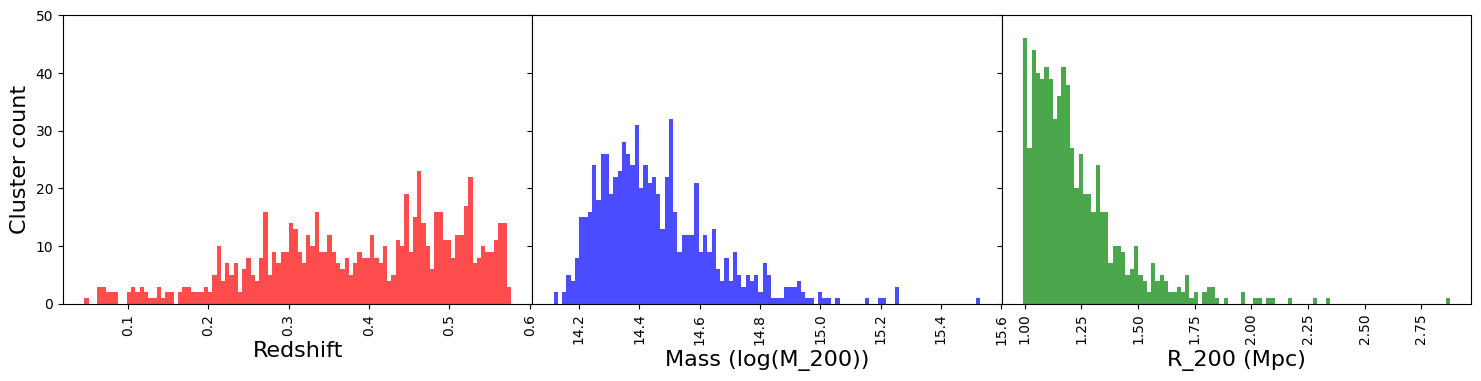

In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(1, 3, wspace=0)  # wspace=0 removes horizontal spacing

# First histogram
ax1 = fig.add_subplot(gs[0])
ax1.hist(redshifts, bins=100, color='red', alpha=0.7)
ax1.set_xlabel('Redshift', fontsize=16)
ax1.set_ylim(0, 50)
ax1.set_ylabel('Cluster count', fontsize=16)


# Second histogram, share y-axis with ax1
ax2 = fig.add_subplot(gs[1], sharey=ax1)
ax2.hist(masses, bins=100, color='blue', alpha=0.7)
ax2.set_xlabel('Mass (log(M_200))', fontsize=16)
plt.setp(ax2.get_yticklabels(), visible=False)  # Hide duplicate y-ticks

# Third histogram, share y-axis again
ax3 = fig.add_subplot(gs[2], sharey=ax1)
ax3.hist(r_200, bins=100, color='green', alpha=0.7)
ax3.set_xlabel('R_200 (Mpc)', fontsize=16)
plt.setp(ax3.get_yticklabels(), visible=False)

for ax in [ax1, ax2, ax3]:
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout(pad=5)
plt.show()



In [8]:
min_len = min(len(df) for df in clean_clusters)
print(f"Min length of clusters: {min_len}")
max_len = max(len(df) for df in clean_clusters)
print(f"Max length of clusters: {max_len}")

Min length of clusters: 50
Max length of clusters: 1169


In [ ]:
#sorted_dfs = [df for _, df in sorted(zip(redshifts, clusters), key=lambda x: x[0])]

substructures = []

for df in clusters:
    
    group_counts = df['haloId'].value_counts() 
    small = 0
    medium = 0
    big =0

    for count in group_counts.values:
        if count < 3:
            small += 1
            continue
        if count < 10:
            medium += 1
            continue
        big += 1

    substructures.append((small, medium, big))





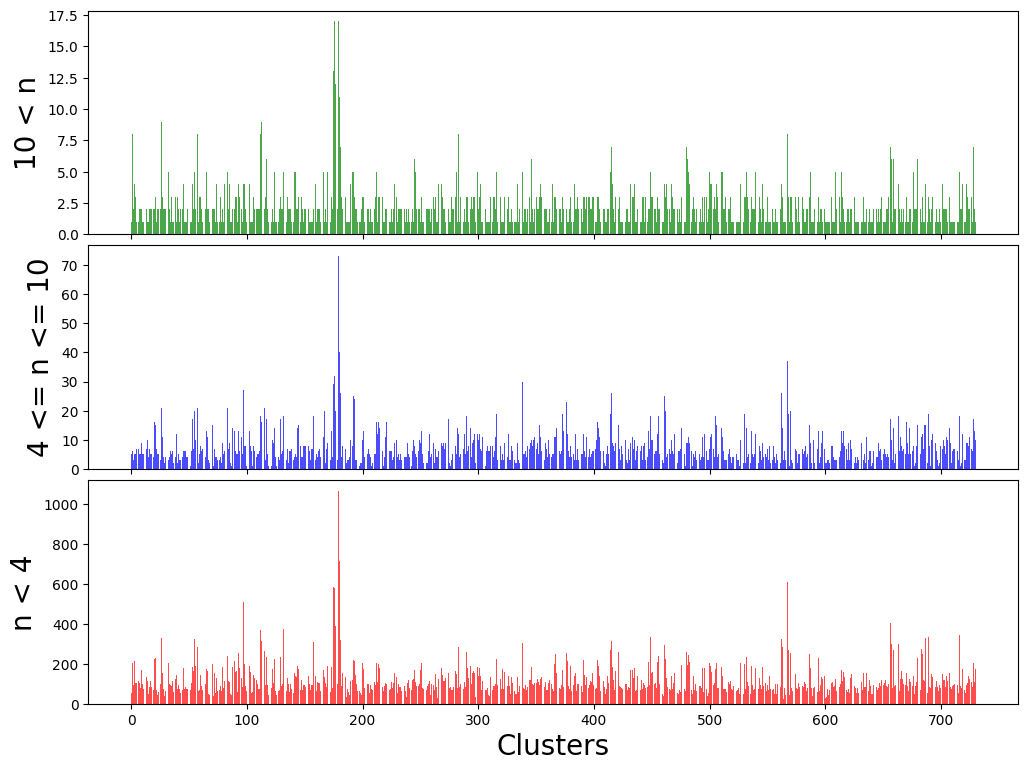

In [10]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

fig = plt.figure(figsize=(12, 9))
gs = gridspec.GridSpec(3, 1, hspace=0.05)  # wspace=0 removes horizontal spacing

small_subs = [s[0] for s in substructures]
medium_subs = [s[1] for s in substructures]
big_subs = [s[2] for s in substructures]
cluster_ids = list(range(len(substructures)))

ax1 = fig.add_subplot(gs[2])
ax1.bar(cluster_ids, small_subs, color='red', alpha=0.7)
ax1.set_ylabel('n < 4', fontsize=20)
ax1.set_xlabel('Clusters', fontsize=20)
plt.setp(ax1.get_yticklabels(), visible=True)
plt.setp(ax1.get_xticklabels(), visible=True)

ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.bar(cluster_ids, medium_subs, color='blue', alpha=0.7)
ax2.set_ylabel('4 <= n <= 10', fontsize=20)
#plt.setp(ax2.get_yticklabels(), visible=True)
plt.setp(ax2.get_xticklabels(), visible=False)

ax3 = fig.add_subplot(gs[0], sharex=ax1)
ax3.bar(cluster_ids, big_subs, color='green', alpha=0.7)
ax3.set_ylabel('10 < n', fontsize=20)
plt.setp(ax3.get_xticklabels(), visible=False)

#plt.tight_layout(pad=3)
plt.show()


0.1388888888888889


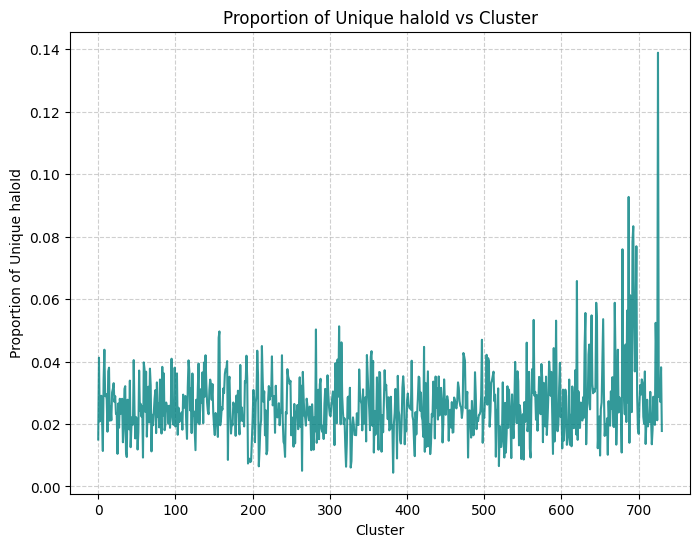

In [11]:

import matplotlib.pyplot as plt

# Calculate the proportion for each DataFrame
proportions = [
    a['haloId'].nunique() / len(b) if len(b) > 0 else 0
    for a, b in zip(clean_clusters, splus_clusters)
]
print(max(proportions))

# Cluster IDs for x-axis
cluster_ids = range(len(clusters))

# Plot as a line graph
plt.figure(figsize=(8, 6))
plt.plot(cluster_ids, proportions, color='teal', alpha=0.8)
plt.xlabel('Cluster')
plt.ylabel('Proportion of Unique haloId')
plt.title('Proportion of Unique haloId vs Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [ ]:
import glob
import os
import pandas as pd

def load_results(sample_type: str):

    folder = f"results_{sample_type}_samples"
    results_df = {}
    
    files = glob.glob(os.path.join(folder, "*.xlsx"))


    for f in files:
        
        xls = pd.ExcelFile(f)
        sheet_names = xls.sheet_names  # skip the first sheet
        
        key = os.path.splitext(os.path.basename(f))[0]

        df_time = pd.read_excel(xls, sheet_name=sheet_names[0])
        df_time = df_time.iloc[:, 0] 

        executions = []
        for name in sheet_names[1:]:
            df = pd.read_excel(xls, sheet_name=name)
            df.columns = df.columns.map(str)
            executions.append(df)
        
        results_df[key] = {"time": df_time, "executions": executions}

    return results_df

In [ ]:
raw_results = load_results("raw")
clean_results = load_results("clean")
splus_results = load_results("splus")

template = raw_results['DSP']

all_results = {
    "raw": raw_results,
    "clean": clean_results,
    "splus": splus_results
}

In [ ]:
import pandas as pd
import os

def overwrite_headers_with_golden_reference(column_names, target_dfs):
    
    for df in target_dfs:
        df.columns = column_names


In [ ]:
keys = ["raw", "clean", "splus"]



In [2]:
import my_data_manager as mdm
import pandas as pd

cat = mdm.load_cat("galaxies_subhalos_zphot.cat")
halos = mdm.separate_halos(cat)
clusters, groups = mdm.separate_clusters(halos)

clean_clusters = [df[df.groupby("haloId")["haloId"].transform("count") > 3].reset_index(drop=True) for df in clusters]

N = 21

splus_clusters = [df[pd.to_numeric(df['mag_r'], errors = 'coerce') >= N].copy() for df in clusters]

#clusters = retag_noise(clusters)
#splus_clusters = retag_noise(splus_clusters)

cluster_samples = {
    "raw": clusters,
    "clean": clean_clusters,
    "splus": splus_clusters
}

/mnt/c/Users/gasep/OneDrive/Documentos/GitHub/ClusteringComparison/ClusteringComparison/my_data_manager.py:53: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(cat, delim_whitespace=True, header=None)
/mnt/c/Users/gasep/OneDrive/Documentos/GitHub/ClusteringComparison/ClusteringComparison/my_data_manager.py:53: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cat, delim_whitespace=True, header=None)


In [3]:
import pandas as pd
import numpy as np

# Baseline: RAW
raw_list = cluster_samples["raw"]
clean_list = cluster_samples["clean"]
splus_list = cluster_samples["splus"]

# Lists to store the survival ratios
clean_ratios = []
splus_ratios = []

# Iterate through the clusters (assuming the lists are ordered the same)
for i in range(len(raw_list)):
    n_raw = len(raw_list[i])
    
    # Avoid division by zero if a raw cluster is somehow empty
    if n_raw == 0:
        continue
        
    # Survival in Clean (Noise filtered)
    n_clean = len(clean_list[i])
    clean_ratios.append(n_clean / n_raw)
    
    # Survival in SPLUS (Magnitude cut)
    n_splus = len(splus_list[i])
    splus_ratios.append(n_splus / n_raw)

# Convert to percentages for the final report
clean_ratios = np.array(clean_ratios) * 100
splus_ratios = np.array(splus_ratios) * 100

# Create the summary table
analysis_data = [
    {
        "Regimen": "CLEAN",
        "Avg Survival (%)": np.mean(clean_ratios),
        "Std Dev (%)": np.std(clean_ratios),
        "Min Survival (%)": np.min(clean_ratios),
        "Max Survival (%)": np.max(clean_ratios)
    },
    {
        "Regimen": "SPLUS",
        "Avg Survival (%)": np.mean(splus_ratios),
        "Std Dev (%)": np.std(splus_ratios),
        "Min Survival (%)": np.min(splus_ratios),
        "Max Survival (%)": np.max(splus_ratios)
    }
]

df_report = pd.DataFrame(analysis_data)

print("--- Per-Cluster Data Survival Analysis ---")
print(df_report.round(2).to_string(index=False))

--- Per-Cluster Data Survival Analysis ---
Regimen  Avg Survival (%)  Std Dev (%)  Min Survival (%)  Max Survival (%)
  CLEAN             49.36         5.79             34.85             74.77
  SPLUS             87.94        12.31             12.77             99.55


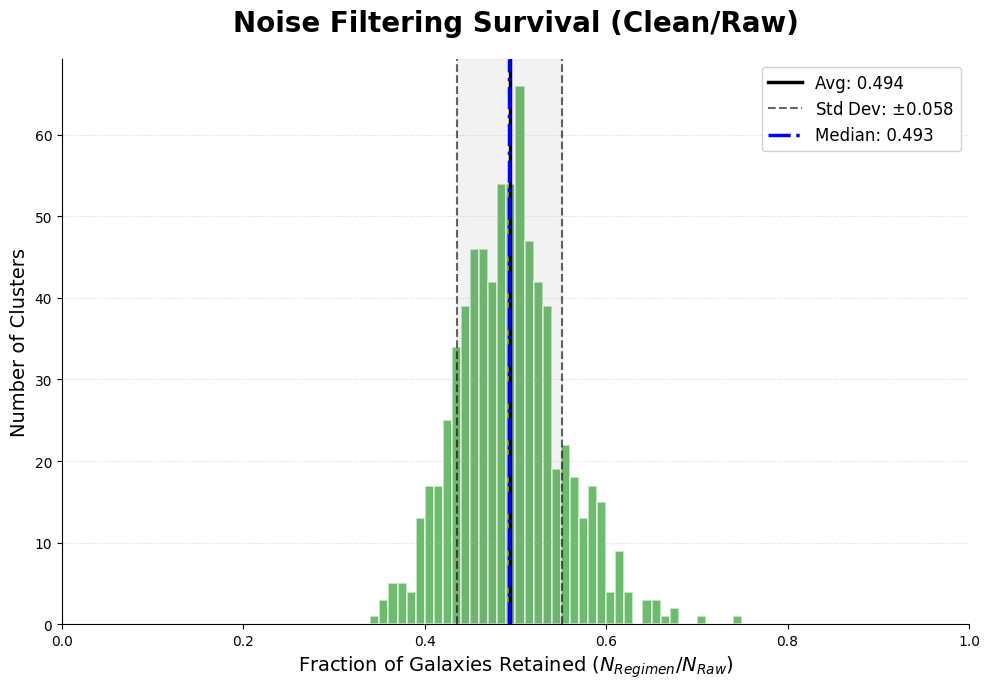

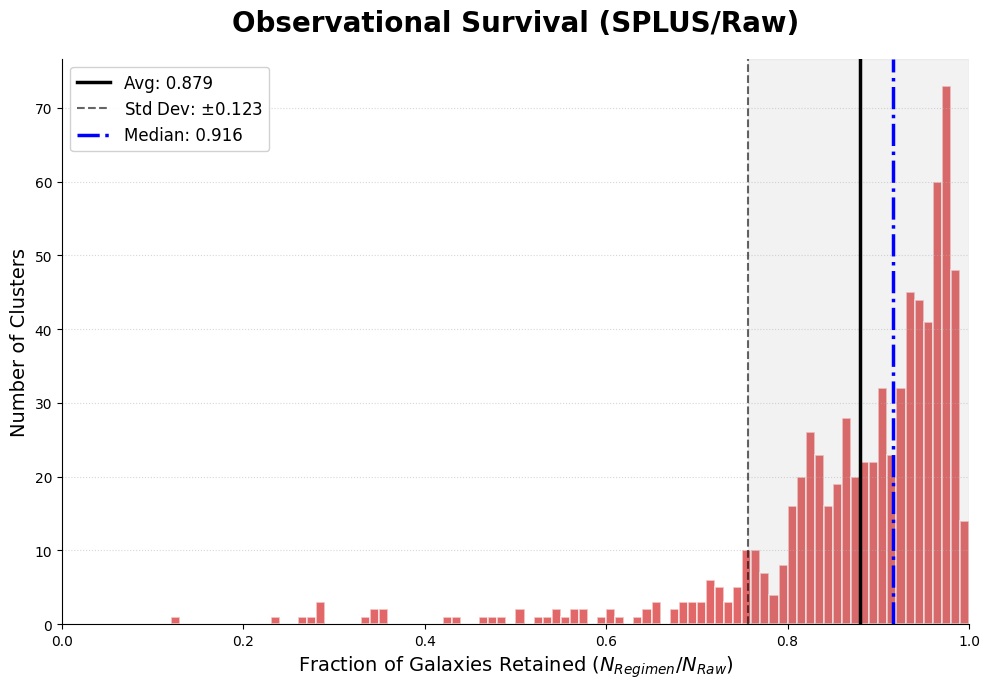

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculate the fractions (0 to 1)
raw_list = cluster_samples["raw"]
clean_list = cluster_samples["clean"]
splus_list = cluster_samples["splus"]

clean_fractions = []
splus_fractions = []

for i in range(len(raw_list)):
    n_raw = len(raw_list[i])
    if n_raw == 0: continue
    
    clean_fractions.append(len(clean_list[i]) / n_raw)
    splus_fractions.append(len(splus_list[i]) / n_raw)

# Convert to numpy for stats
clean_fractions = np.array(clean_fractions)
splus_fractions = np.array(splus_fractions)

# 2. Define Plotting Helper
def save_survival_histogram(data, title, filename, color):
    avg = np.mean(data)
    std = np.std(data)
    median = np.median(data)
    
    plt.figure(figsize=(10, 7))
    
    # Histogram
    counts, bins, patches = plt.hist(data, bins=100, range=(0, 1), 
                                     color=color, alpha=0.7, 
                                     edgecolor='white', linewidth=1.2)
    
    # Marking Statistics
    plt.axvline(avg, color='black', linestyle='-', linewidth=2.5, 
                label=f'Avg: {avg:.3f}')
    
    # Marking Std Dev with dashed lines
    plt.axvline(avg - std, color='black', linestyle='--', linewidth=1.5, alpha=0.6,
                label=f'Std Dev: $\pm${std:.3f}')
    plt.axvline(avg + std, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
    
    # Shading the Std Dev region
    plt.axvspan(max(0, avg - std), min(1, avg + std), color='gray', alpha=0.1)

    plt.axvline(median, color='blue', linestyle='-.', linewidth=2.5, label=f'Median: {median:.3f}')

    # Aesthetics
    plt.title(title, fontsize=20, fontweight='bold', pad=20)
    plt.xlabel("Fraction of Galaxies Retained ($N_{Regimen} / N_{Raw}$)", fontsize=14)
    plt.ylabel("Number of Clusters", fontsize=14)
    plt.xlim(0, 1)
    
    # Ensure Y-axis uses integers for counts
    plt.gca().yaxis.get_major_locator().set_params(integer=True)
    
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.legend(fontsize=12, frameon=True, facecolor='white', framealpha=0.9)
    
    # Clean spines
    for spine in ['top', 'right']:
        plt.gca().spines[spine].set_visible(False)
        
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()
    plt.close()

# 3. Generate Separated Plots
save_survival_histogram(clean_fractions, "Noise Filtering Survival (Clean/Raw)", 
                         "histogram_clean_survival.png", "#2ca02c")

save_survival_histogram(splus_fractions, "Observational Survival (SPLUS/Raw)", 
                         "histogram_splus_survival.png", "#d62728")

In [ ]:
sample_df = cluster_samples["raw"][0]

# Check the coordinate ranges
ra_min, ra_max = sample_df["RA"].astype(float).min(), sample_df["RA"].astype(float).max()
dec_min, dec_max = sample_df["DEC"].astype(float).min(), sample_df["DEC"].astype(float).max()

print(f"--- Coordinate Range Check ---")
print(f"RA Range:  {ra_min:.4f} to {ra_max:.4f}")
print(f"DEC Range: {dec_min:.4f} to {dec_max:.4f}")

# Logic to determine units
if ra_max > 24:
    print("\nResult: RA is definitely in DEGREES (0-360 range).")
elif ra_max <= 24 and ra_min >= 0:
    print("\nResult: RA could be in HOURS (0-24). Check if values are decimals or hms.")
else:
    print("\nResult: Unusual RA range. Verify if coordinates are relative to center.")

if dec_min < -90 or dec_max > 90:
    print("Result: DEC is likely NOT in degrees. Check for arcseconds or other units.")
else:
    print("Result: DEC is in DEGREES (-90 to +90 range).")